<a href="https://colab.research.google.com/github/SadidNj/CVPR_Project/blob/main/New_CNN_22_49128_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
import numpy as np
import os

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
import os

# Path to your dataset folder
data_dir = './Rice_Image_Dataset'

# Check if the initial data_dir exists and its contents
if not os.path.exists(data_dir):
    print(f"Error: Directory '{data_dir}' not found.")
else:
    print(f"Contents of '{data_dir}': {os.listdir(data_dir)}")
    # Assuming there might be a nested directory, adjust data_dir if necessary
    # For example, if it's data_dir/Rice_Image_Dataset/..., then:
    nested_dir_check = os.path.join(data_dir, 'Rice_Image_Dataset')
    if os.path.exists(nested_dir_check) and os.path.isdir(nested_dir_check):
        data_dir = nested_dir_check
        print(f"Adjusted data_dir to: {data_dir}")
    else:
        print("No nested 'Rice_Image_Dataset' directory found, using original path.")

# Initial transform for exploration
explore_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

full_dataset = datasets.ImageFolder(root=data_dir, transform=explore_transform)
classes = full_dataset.classes
print(f"Total Images: {len(full_dataset)}")
print(f"Classes: {classes}")

Contents of './Rice_Image_Dataset': ['Rice_Image_Dataset']
Adjusted data_dir to: ./Rice_Image_Dataset/Rice_Image_Dataset
Total Images: 75000
Classes: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


In [ ]:
# Training Augmentation
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Validation/Test Transform
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Splitting: 80% Train, 10% Val, 10% Test [cite: 11]
train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_data, val_data, test_data = random_split(full_dataset, [train_size, val_size, test_size])

# Apply specific transforms
train_data.dataset.transform = train_transform
val_data.dataset.transform = val_transform
test_data.dataset.transform = val_transform

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [ ]:
class RiceCNN(nn.Module):
    def __init__(self):
        super(RiceCNN, self).__init__()

        # Block 1: Conv -> BN -> ReLU -> Pool
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Block 2: Conv -> BN -> ReLU -> Pool
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

        # Fully Connected Layers
        self.fc1 = nn.Linear(64 * 16 * 16, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 5)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = RiceCNN().to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)

epochs = 5
history = {'train_loss': [], 'val_acc': []}

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    history['train_loss'].append(running_loss/len(train_loader))
    history['val_acc'].append(val_acc)
    scheduler.step()

    print(f"Epoch {epoch+1}: Loss {running_loss/len(train_loader):.4f}, Val Acc {val_acc:.2f}%")

Epoch 1: Loss 0.1430, Val Acc 99.17%
Epoch 2: Loss 0.0546, Val Acc 98.91%
Epoch 3: Loss 0.0260, Val Acc 99.44%
Epoch 4: Loss 0.0214, Val Acc 99.57%
Epoch 5: Loss 0.0180, Val Acc 99.60%


In [ ]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes))


Classification Report:
              precision    recall  f1-score   support

     Arborio       0.99      0.99      0.99      1538
     Basmati       1.00      0.99      1.00      1456
      Ipsala       1.00      1.00      1.00      1460
     Jasmine       0.99      1.00      1.00      1581
   Karacadag       0.99      0.99      0.99      1465

    accuracy                           1.00      7500
   macro avg       1.00      1.00      1.00      7500
weighted avg       1.00      1.00      1.00      7500



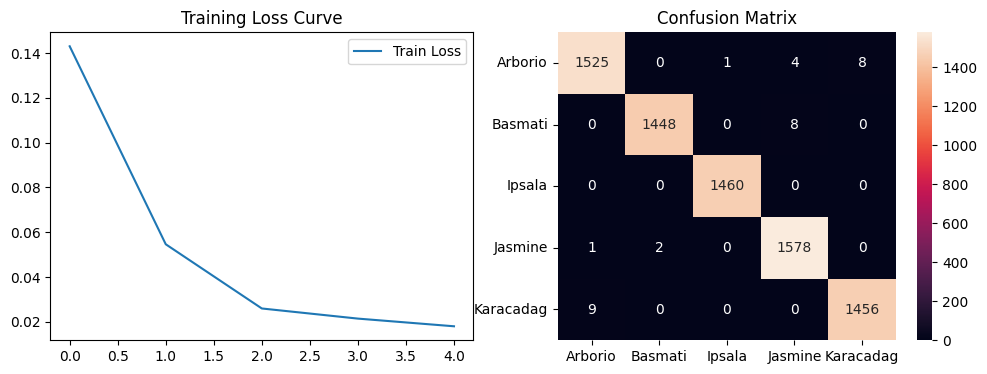

In [ ]:
# Plot Training Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.title('Training Loss Curve')
plt.legend()

# Plot Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Save the trained model weights [cite: 44]
torch.save(model.state_dict(), 'CNN_22-49128-3.pth')